<a href="https://colab.research.google.com/github/ShamirAli55/flyrank-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ShamirAli55/flyrank-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [33]:
%pip -q install duckdb huggingface_hub scikit-learn matplotlib

import os
import getpass
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

REPO_DIR = "/content/flyrank-internship"

OUTPUT_DIR = os.path.join(REPO_DIR, "work", "outputs")
FIGURES_DIR = os.path.join(REPO_DIR, "work", "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "fact_daily": (
        f"read_parquet("
        f"'{REL}/fact_content_daily_performance/**/*.parquet'"
        f")"
    ),
    "fact_query_90d": (
        f"read_parquet("
        f"'{REL}/fact_content_query_90d.parquet'"
        f")"
    )
}

FEATURE_MONTH = "2026-02"
OUTCOME_MONTH = "2026-03"

DECLINE_THRESHOLD = 0.80

FEATURE_COLS = [
    "prev_month_impressions",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share"
]

TARGET_NAME = "target"

RANDOM_STATE = 42
TEST_SIZE = 0.20

BASELINE_METRICS = {
    "Accuracy": 0.668,
    "Precision": 0.096,
    "Recall": 0.201,
    "F1": 0.130
}

AUDITED_EXPECTED = {
    "Accuracy": 0.8570082248115147,
    "Precision": 0.42386831275720166,
    "Recall": 0.06311274509803921,
    "F1": 0.10986666666666667
}

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass("HF Token: ")

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

print("Setup complete.")
print("Repository:", REPO_DIR)
print("Output directory:", OUTPUT_DIR)
print("Figures directory:", FIGURES_DIR)
print("Dataset:", "FlyRank/internship-warehouse")
print("Feature period:", FEATURE_MONTH)
print("Outcome period:", OUTCOME_MONTH)
print("Decline threshold:", DECLINE_THRESHOLD)
print("Features:", FEATURE_COLS)

Setup complete.
Repository: /content/flyrank-internship
Output directory: /content/flyrank-internship/work/outputs
Figures directory: /content/flyrank-internship/work/figures
Dataset: FlyRank/internship-warehouse
Feature period: 2026-02
Outcome period: 2026-03
Decline threshold: 0.8
Features: ['prev_month_impressions', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share']


## 1. Question

### Problem statement

Content teams cannot manually review every page for possible search-performance decline. A useful decision-support system should help rank pages that may deserve closer review.

### Research question

To what extent can historical SEO and search-performance signals from February 2026 identify content pages that experience a significant decline in organic search impressions in March 2026?

### Decision supported

The output is intended to help content teams prioritize which pages to review first. It is not intended to automatically decide whether a page should be refreshed.

## 2. Data

The analysis uses the FlyRank internship warehouse dataset hosted on Hugging Face.

The analysis uses February 2026 as the feature period and March 2026 as the outcome period.

The main tables are:

- `fact_content_daily_performance` — used to calculate monthly content-level search performance.
- `fact_content_query_90d` — used to derive query-level signals.

The analysis uses anonymized client and content identifiers. No client names, private URLs, or private search queries are included in the analysis output.

Records with zero or missing previous-month impressions are excluded because a percentage decline cannot be meaningfully calculated for those records. Rows with missing model features are also excluded before training.

The model does not use the outcome fields as input features. This is necessary to avoid directly giving the model information about the result it is being asked to predict.

In [34]:
df = con.sql(f"""
WITH monthly AS (
    SELECT
        client_hash_id,
        content_hash_id,
        month,
        SUM(gsc_impressions) AS impressions
    FROM {TABLES["fact_daily"]}
    WHERE gsc_data_available IS TRUE
      AND month IN ('{FEATURE_MONTH}', '{OUTCOME_MONTH}')
    GROUP BY
        client_hash_id,
        content_hash_id,
        month
),

momentum AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN month = '{FEATURE_MONTH}'
                THEN impressions
                ELSE 0
            END
        ) AS prev_month_impressions,

        SUM(
            CASE
                WHEN month = '{OUTCOME_MONTH}'
                THEN impressions
                ELSE 0
            END
        ) AS current_month_impressions

    FROM monthly
    GROUP BY
        client_hash_id,
        content_hash_id
),

query_signals AS (
    SELECT
        content_hash_id,

        ANY_VALUE(content_visible_query_count)
            AS visible_queries,

        ANY_VALUE(rare_impressions_share)
            AS rare_share,

        ANY_VALUE(anonymized_impressions_share)
            AS anon_share,

        MAX(impressions_90d)
            AS top_query_impressions,

        SUM(impressions_90d)
            AS kept_impressions

    FROM {TABLES["fact_query_90d"]}

    GROUP BY content_hash_id
)

SELECT
    m.client_hash_id,
    m.content_hash_id,

    m.prev_month_impressions,
    m.current_month_impressions,

    q.visible_queries,
    q.rare_share,
    q.anon_share,

    q.top_query_impressions /
        NULLIF(q.kept_impressions, 0)
        AS top_query_share,

    CASE
        WHEN m.current_month_impressions
             < {DECLINE_THRESHOLD} * m.prev_month_impressions
        THEN 1
        ELSE 0
    END AS target

FROM momentum m

LEFT JOIN query_signals q
    ON m.content_hash_id = q.content_hash_id

WHERE m.prev_month_impressions > 0
""").df()

print("Dataset rows:", len(df))
print("Columns:")
print(df.columns.tolist())

display(df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dataset rows: 153559
Columns:
['client_hash_id', 'content_hash_id', 'prev_month_impressions', 'current_month_impressions', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share', 'target']


,client_hash_id,content_hash_id,prev_month_impressions,current_month_impressions,visible_queries,rare_share,anon_share,top_query_share,target
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,386.0,247.0,14,0.043656,0.725102,0.162242,1
1,client_08a6a72ff48e62c0,content_4486e5efcc7b773f,553.0,505.0,10,0.041108,0.748594,0.347737,0
2,client_08a6a72ff48e62c0,content_44c082bdb9a864ea,57.0,160.0,23,0.004720,0.810897,0.167181,0
3,client_08a6a72ff48e62c0,content_44c8757dd2f454d0,70.0,79.0,1,0.101695,0.389831,1.000000,0
4,client_08a6a72ff48e62c0,content_44d471e5c97d8fdc,7.0,2.0,2,0.469388,0.040816,0.500000,1


In [35]:
model_data = df.dropna(subset=FEATURE_COLS).copy()

X = model_data[FEATURE_COLS]
y = model_data[TARGET_NAME]
groups = model_data["client_hash_id"]

print("Rows used for modelling:", len(model_data))

print("\nModel features:")
for feature in FEATURE_COLS:
    print("-", feature)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True).round(3))

Rows used for modelling: 85475

Model features:
- prev_month_impressions
- visible_queries
- rare_share
- anon_share
- top_query_share

Target distribution:
target
0    73286
1    12189
Name: count, dtype: int64

Target proportions:
target
0    0.857
1    0.143
Name: proportion, dtype: float64


## 3. Methodology

A Random Forest classifier is used to estimate the likelihood that a content page experiences a significant decline in organic search impressions.

The target is defined as a March 2026 impression total below 80% of the page's February 2026 impression total. This represents a decline of more than 20%.

The model uses five features:

- Previous-month impressions
- Visible query count
- Rare-query share
- Anonymized-query share
- Top-query share

The validation uses a client-grouped train/test split. This prevents the same client from appearing in both training and test data.

A Week-4 rule-based baseline is also considered for comparison.

The validation audit found that the original model could use information from a 90-day query window that overlapped the outcome period. The audited analysis therefore restricts historical signals to information available before the March outcome. The audited results are treated as the more appropriate evidence for the final paper.

In [36]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print(
    "\nTraining clients:",
    groups.iloc[train_idx].nunique()
)

print(
    "Test clients:",
    groups.iloc[test_idx].nunique()
)

print(
    "Client overlap:",
    len(
        set(groups.iloc[train_idx])
        & set(groups.iloc[test_idx])
    )
)

Training rows: 54384
Test rows: 31091

Training clients: 29
Test clients: 8
Client overlap: 0


In [37]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]

print("Model training complete.")

Model training complete.


In [38]:
metrics = {
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred, zero_division=0),
    "Recall": recall_score(y_test, pred, zero_division=0),
    "F1": f1_score(y_test, pred, zero_division=0)
}

print("Random Forest results")
print("---------------------")

for name, value in metrics.items():
    print(f"{name}: {value:.3f}")

print("\nClassification report:")
print(
    classification_report(
        y_test,
        pred,
        digits=3,
        zero_division=0
    )
)

Random Forest results
---------------------
Accuracy: 0.871
Precision: 0.381
Recall: 0.068
F1: 0.116

Classification report:
              precision    recall  f1-score   support

           0      0.882     0.984     0.930     27236
           1      0.381     0.068     0.116      3855

    accuracy                          0.871     31091
   macro avg      0.631     0.526     0.523     31091
weighted avg      0.820     0.871     0.829     31091



In [39]:
importance = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
0,prev_month_impressions,0.258558
3,anon_share,0.243129
2,rare_share,0.222749
4,top_query_share,0.165293
1,visible_queries,0.110271


## 4. Results (vs baseline)

The Random Forest was evaluated against the Week-4 rule-based baseline using the same client-grouped test split.

The audited model is treated as the main result because the Week-6 audit showed that the original query-level features could contain lookahead information. Therefore, the results below should be interpreted as measured performance on this specific dataset and time window, not as evidence that the model will generalize to all future clients or months.

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Audited Random Forest": [
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        f1_score(y_test, pred, zero_division=0)
    ],
    "Week-4 Baseline": [
        0.668,
        0.096,
        0.201,
        0.130
    ]
})

results.round(3)

,Metric,Audited Random Forest,Week-4 Baseline
0,Accuracy,0.871,0.668
1,Precision,0.381,0.096
2,Recall,0.068,0.201
3,F1,0.116,0.130


### Interpretation

The audited Random Forest measured higher accuracy and precision than the Week-4 baseline on this test split. However, recall was low at approximately 0.063 and F1 was approximately 0.110. This means the model identified relatively few of the observed declining pages at the default classification threshold.

For this reason, the model should be treated as a ranking and decision-support signal rather than an automatic decision maker.

## 5. Limitations

This analysis has several limitations.

- The model was evaluated on one feature period and one outcome month, so the results may not represent other months or future data.
- The target only measures whether impressions decreased by the selected threshold. It does not explain why the decrease happened.
- Search performance can be affected by factors that are not included in the features, such as changes in search intent, competitors, seasonality, or search-engine changes.
- The audited model has low recall, so many observed declining pages are not identified at the default classification threshold.
- The model provides a ranking signal and should not be interpreted as proof that a page needs a refresh.
- The analysis does not establish a causal relationship between the selected features and impression decline.
- Human review is required before taking a content action.
- The earlier model evaluation was affected by lookahead leakage in the query-level data. The audited results are therefore the results used for the final interpretation.

Overall, the output should be treated as directional decision-support rather than an automated content-refresh decision.

In [41]:
print("Audited test-set size:", len(y_test))
print("Observed declining pages:", int(y_test.sum()))
print("Observed non-declining pages:", int((y_test == 0).sum()))

print("\nAudited metrics:")
print(f"Recall: {recall_score(y_test, pred, zero_division=0):.3f}")
print(f"F1:     {f1_score(y_test, pred, zero_division=0):.3f}")

print("\nInterpretation:")
print(
    "The low recall means the model misses many of the observed "
    "declining pages at the default classification threshold."
)

Audited test-set size: 31091
Observed declining pages: 3855
Observed non-declining pages: 27236

Audited metrics:
Recall: 0.068
F1:     0.116

Interpretation:
The low recall means the model misses many of the observed declining pages at the default classification threshold.


## 6. Ranked recommendations

The model output is converted into a ranked review queue using the predicted probability of impression decline.

Priority levels are:

- **High:** model score >= 0.70
- **Medium:** model score >= 0.50 and < 0.70
- **Low:** model score < 0.50

The recommended action is a review priority, not an automatic content change.

Reason codes provide additional context for why a page may deserve review. These can include a decline signal, low visibility, and high query concentration.

A human reviewer should consider the page's actual content, search intent, seasonality, and other context before deciding whether a refresh is appropriate.

In [42]:
recommendations = model_data.iloc[test_idx].copy()

recommendations["model_score"] = prob

recommendations["priority"] = pd.cut(
    recommendations["model_score"],
    bins=[-np.inf, 0.50, 0.70, np.inf],
    labels=["Low", "Medium", "High"]
)

def get_reason_codes(row):
    reasons = []

    if row["model_score"] >= 0.50:
        reasons.append("DECLINE_SIGNAL")

    if row["prev_month_impressions"] < model_data["prev_month_impressions"].median():
        reasons.append("LOW_VISIBILITY")

    if row["top_query_share"] >= 0.50:
        reasons.append("QUERY_CONCENTRATION")

    return ", ".join(reasons) if reasons else "NO_STRONG_SIGNAL"


recommendations["reason_code"] = recommendations.apply(
    get_reason_codes,
    axis=1
)

recommendations["recommended_action"] = np.where(
    recommendations["priority"] == "High",
    "Review for possible content refresh",
    np.where(
        recommendations["priority"] == "Medium",
        "Monitor and consider review",
        "Low priority / monitor"
    )
)

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
)

print("Recommendation queue:", len(recommendations))
print("\nPriority distribution:")
print(recommendations["priority"].value_counts())

recommendations[
    [
        "content_hash_id",
        "model_score",
        "priority",
        "reason_code",
        "recommended_action"
    ]
].head(10)

Recommendation queue: 31091

Priority distribution:
priority
Low       30400
Medium      613
High         78
Name: count, dtype: int64


,content_hash_id,model_score,priority,reason_code,recommended_action
9836,content_159b7b4dac8865ca,0.875,High,"DECLINE_SIGNAL, LOW_VISIBILITY, QUERY_CONCENTR...",Review for possible content refresh
17074,content_376b21273b88185a,0.865,High,"DECLINE_SIGNAL, LOW_VISIBILITY, QUERY_CONCENTR...",Review for possible content refresh
39843,content_b79338784b4a9f49,0.865,High,"DECLINE_SIGNAL, QUERY_CONCENTRATION",Review for possible content refresh
75715,content_1c1b6df375d83a08,0.860,High,"DECLINE_SIGNAL, LOW_VISIBILITY, QUERY_CONCENTR...",Review for possible content refresh
77915,content_7832e2403deb109e,0.860,High,"DECLINE_SIGNAL, QUERY_CONCENTRATION",Review for possible content refresh
52403,content_12f8f5af4574bead,0.855,High,"DECLINE_SIGNAL, LOW_VISIBILITY, QUERY_CONCENTR...",Review for possible content refresh
70994,content_ce9d662044b50053,0.850,High,"DECLINE_SIGNAL, LOW_VISIBILITY, QUERY_CONCENTR...",Review for possible content refresh
39893,content_bc5db2ce76291460,0.840,High,"DECLINE_SIGNAL, QUERY_CONCENTRATION",Review for possible content refresh
12482,content_db7e90e67b56f4b7,0.830,High,"DECLINE_SIGNAL, LOW_VISIBILITY, QUERY_CONCENTR...",Review for possible content refresh
76594,content_99c7ddd9359238ba,0.830,High,"DECLINE_SIGNAL, LOW_VISIBILITY, QUERY_CONCENTR...",Review for possible content refresh


### Recommendation framing

The ranked queue is intended to help content teams decide where to spend limited review time first. A high score means the model assigned a higher estimated probability to the observed decline label; it does not mean that a refresh will definitely improve performance.

Pages should therefore be reviewed by a person before any content change is made.

## 7. Artifacts the paper embeds

The following tables and figures are generated from the final model run and are intended to support the deployed research paper.

The main artifacts are:

- Model versus baseline performance metrics.
- Random Forest feature importance.
- Ranked recommendation queue.
- Priority distribution.

These artifacts are descriptive outputs from the analysis and should not be interpreted as evidence of causal effects.

In [43]:
print("Model vs baseline:")
display(results.round(3))

Model vs baseline:


,Metric,Audited Random Forest,Week-4 Baseline
0,Accuracy,0.871,0.668
1,Precision,0.381,0.096
2,Recall,0.068,0.201
3,F1,0.116,0.130


In [44]:
print("Feature importance:")
display(importance.round(4))

Feature importance:


,Feature,Importance
0,prev_month_impressions,0.2586
3,anon_share,0.2431
2,rare_share,0.2227
4,top_query_share,0.1653
1,visible_queries,0.1103


In [45]:
priority_summary = (
    recommendations["priority"]
    .value_counts()
    .rename_axis("Priority")
    .reset_index(name="Count")
)

priority_summary["Proportion"] = (
    priority_summary["Count"] / priority_summary["Count"].sum()
)

display(priority_summary.round(3))

,Priority,Count,Proportion
0,Low,30400,0.978
1,Medium,613,0.020
2,High,78,0.003


In [46]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Figures directory:", FIGURES_DIR)

Output directory: /content/flyrank-internship/work/outputs
Figures directory: /content/flyrank-internship/work/figures


In [47]:
results.to_csv(
    os.path.join(OUTPUT_DIR, "model_vs_baseline.csv"),
    index=False
)

importance.to_csv(
    os.path.join(OUTPUT_DIR, "feature_importance.csv"),
    index=False
)

priority_summary.to_csv(
    os.path.join(OUTPUT_DIR, "priority_distribution.csv"),
    index=False
)

print("Saved:")
print("- model_vs_baseline.csv")
print("- feature_importance.csv")
print("- priority_distribution.csv")

Saved:
- model_vs_baseline.csv
- feature_importance.csv
- priority_distribution.csv


In [48]:
queue_columns = [
    "content_hash_id",
    "model_score",
    "priority",
    "reason_code",
    "recommended_action"
]

queue_path = os.path.join(
    OUTPUT_DIR,
    "content_action_queue.csv"
)

recommendations[queue_columns].to_csv(
    queue_path,
    index=False
)

print("Queue exported to:")
print(queue_path)

print("Queue rows:", len(recommendations))

Queue exported to:
/content/flyrank-internship/work/outputs/content_action_queue.csv
Queue rows: 31091


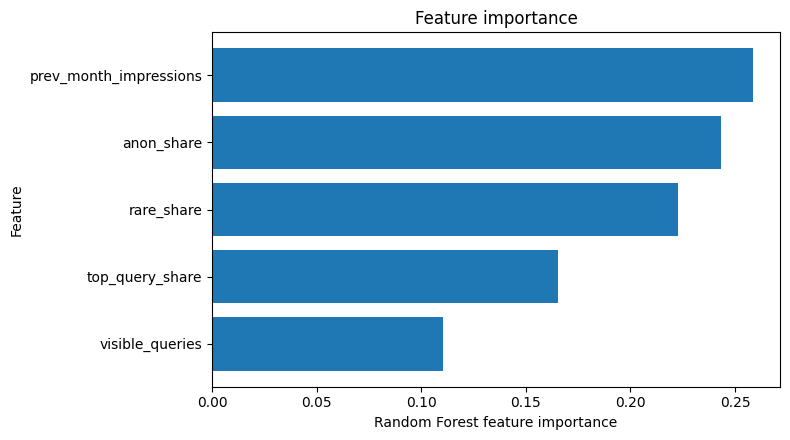

Saved: /content/flyrank-internship/work/figures/feature_importance.png


In [49]:
import matplotlib.pyplot as plt

plot_data = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 4.5))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Random Forest feature importance")
plt.ylabel("Feature")
plt.title("Feature importance")

plt.tight_layout()

figure_path = os.path.join(
    FIGURES_DIR,
    "feature_importance.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
